[autoreload of dnafiber.postprocess.fiber failed: Traceback (most recent call last):
  File "/home/clement/miniforge-pypy3/envs/dl/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/clement/miniforge-pypy3/envs/dl/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/clement/miniforge-pypy3/envs/dl/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/clement/miniforge-pypy3/envs/dl/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/home/clement/miniforge-pypy3/envs/dl/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 323, in update_instances
    object.__setattr__(ref, "__class__", new)
TypeError: __class__ assignment: 'Bbox' object layout differs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


TypeError: descriptor 'x' for 'Bbox' objects doesn't apply to a 'Bbox' object

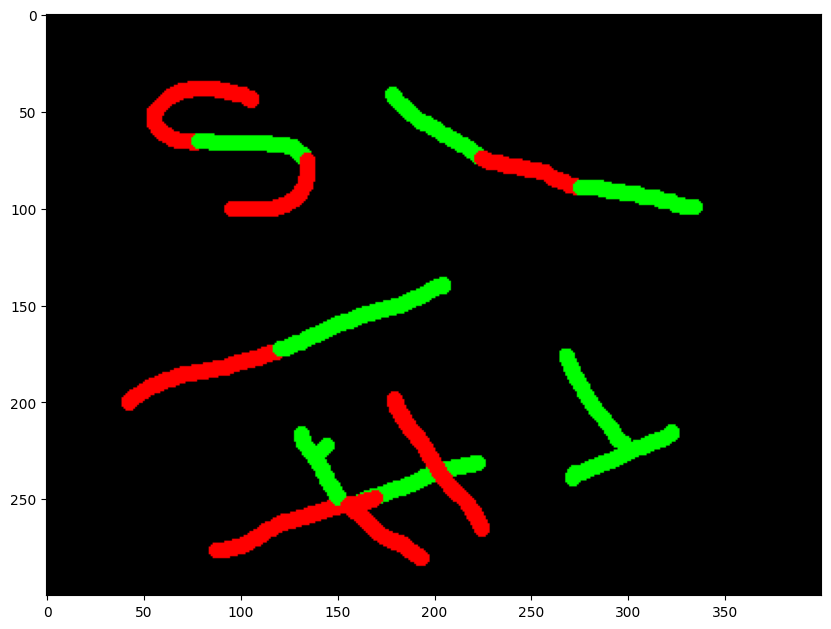

In [3]:
%load_ext autoreload
%autoreload 2
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from skimage.morphology import skeletonize
from skimage.measure import label
from dnafiber.data.utils import mask_filepath_to_fibers
from dnafiber.data.consts import CMAP, CMAP_NO_ALPHA
from dnafiber.postprocess.core import Fibers, FiberProps
from dnafiber.data.utils import extract_fibers


path = "../test/test.png"
cmap = ["black", "pink", "blue"]
img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)
h, w = img.shape[:2]
mask = np.zeros((h, w), dtype=np.uint8)
mask[img[:, :, 0] > 0] = 1
mask[img[:, :, 1] > 0] = 2

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask, cmap=CMAP_NO_ALPHA, vmin=0, vmax=2)
fibers = extract_fibers(mask)

for f in fibers:
    trace, labels = f.get_labelled_trace()
    trace = trace.copy()
    bbox = f.bbox
    x, y, w, h = bbox
    trace[:, 1] += x
    trace[:, 0] += y
    colors = np.array([cmap[label] for label in labels])
    ax.scatter(trace[:, 1], trace[:, 0], c=colors, s=1)
    skeleton = np.zeros_like(img)
    skeleton[trace[:, 0], trace[:, 1]] = 255
    # Draw the bounding box
    rect = plt.Rectangle((x, y), w, h, edgecolor="white", facecolor="none", linewidth=1)
    ax.add_patch(rect)
    # Remove grid, ticks and axis
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

fig.show()

Extracted fiber length: 217.79 pixels (expected: 217 pixels)


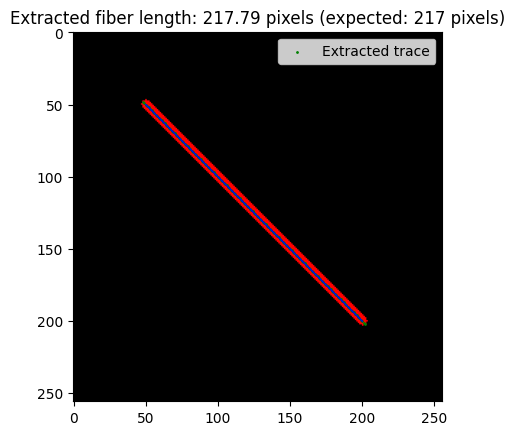

In [ ]:
fake_image = np.zeros((256, 256), dtype=np.uint8)

start_point = (50, 50)
end_point = (200, 200)
thickness = 5
cv2.line(fake_image, start_point, end_point, color=1, thickness=thickness)
length = int(np.linalg.norm(np.array(end_point) - np.array(start_point))) + thickness
fibers = extract_fibers(fake_image)

plt.imshow(fake_image, cmap=CMAP_NO_ALPHA, vmin=0, vmax=2)
plt.plot(
    [start_point[1], end_point[1]],
    [start_point[0], end_point[0]],
    color="blue",
    linewidth=1,
)

trace = fibers[0].get_trace().copy()
trace[:, 1] += fibers[0].bbox[0]
trace[:, 0] += fibers[0].bbox[1]

plt.scatter(trace[:, 1], trace[:, 0], color="green", s=1, label="Extracted trace")

plt.title(
    f"Extracted fiber length: {fibers[0].length:.2f} pixels (expected: {length} pixels)"
)
print(
    f"Extracted fiber length: {fibers[0].length:.2f} pixels (expected: {length} pixels)"
)
plt.legend()
plt.show()